## 12.01 图像增广


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"

from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear


---


### 练习 12.1.1

**题目：** 在不使用图像增广的情况下训练模型：`train_with_data_aug(no_aug, no_aug)`。比较使用和不使用图像增广的训练结果和测试精度。这个对比实验能支持图像增广可以减轻过拟合的论点吗？为什么？

**解答：**

&emsp;&emsp;分别对采用图像增广和不采用图像增广的训练样本进行训练，并测试其分类精度。实验证明使用水平翻转这一简单图像增广技术可以有效减轻过拟合问题：不使用图像增广时，训练精度持续上升而测试精度徘徊不升甚至下降，过拟合明显；使用图像增广时，训练与测试精度都更平稳，最终的分类精度也更高。

&emsp;&emsp;该对比支持“图像增广可以减轻过拟合”的论点：图像增广通过对训练样本施加随机变化（如水平翻转），扩大了有效训练集的规模与多样性，使模型不过分依赖图像的某些属性（如目标朝向），从而提升泛化能力。

以下使用 `torch` 编程进行验证（无增广 vs 水平翻转增广，各训练10个迭代周期）：


In [6]:
import hashlib
import os
import torchvision.datasets.cifar as cifar_mod

# 预置数据兼容：本 notebook 随章附带的 CIFAR-10 为转换后的 torchvision 格式，
# 用本地文件实际哈希重建校验表（若为官方联网下载的数据则自动跳过此分支）
_base = '../data/cifar-10-batches-py'
def _local_md5(p):
    h = hashlib.md5()
    with open(p, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()
if os.path.exists(os.path.join(_base, 'data_batch_1')) and \
   os.path.exists(os.path.join(_base, 'test_batch')):
    cifar_mod.CIFAR10.train_list = [
        (f'data_batch_{i + 1}', _local_md5(f'{_base}/data_batch_{i + 1}'))
        for i in range(5)]
    cifar_mod.CIFAR10.test_list = [('test_batch', _local_md5(f'{_base}/test_batch'))]
    cifar_mod.CIFAR10.meta = {'filename': 'batches.meta', 'key': 'label_names',
                              'md5': _local_md5(f'{_base}/batches.meta')}

all_images = torchvision.datasets.CIFAR10(train=True, root="../data",
                                          download=True)
print(f'CIFAR-10 训练集大小: {len(all_images)}')

CIFAR-10 训练集大小: 50000


In [7]:
# 图像增广方法
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),  # 水平翻转
    torchvision.transforms.ToTensor()])
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()])

def load_cifar10(is_train, augs, batch_size):
    dataset = torchvision.datasets.CIFAR10(root="../data", train=is_train,
                                           transform=augs, download=True)
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                       shuffle=is_train, num_workers=0)

/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torch/autograd/__init__.py:221: UserWarning: Cannot create tensor with interal format while allow_internel_format=False, tensor will be created with base format. (Triggered internally at ../torch_npu/csrc/aten/common/TensorFactories.cpp:340.)
  torch.ones_like(out, memory_format=torch.preserve_format)
loss 0.279, train acc 0.899, test acc 0.566
5633.8 examples/sec on npu:1


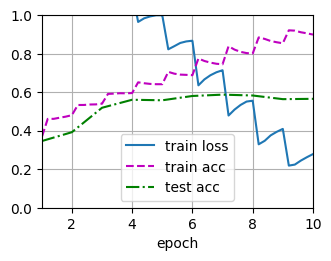

In [8]:
batch_size, num_epochs = 256, 10

def train_with_data_aug(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction="none")
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, device)

def init_weights(m):
    if type(m) in (nn.Linear, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)

# 不使用图像增广（train 也用 test_augs）
net = resnet18(10, 3)
net.apply(init_weights)
train_with_data_aug(test_augs, test_augs, net)

loss 0.662, train acc 0.766, test acc 0.605
5648.3 examples/sec on npu:1


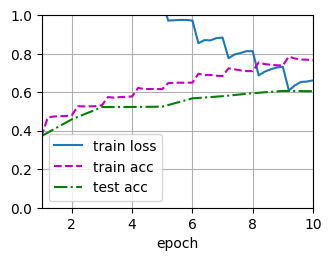

In [9]:
# 使用图像增广（水平翻转）
net = resnet18(10, 3)
net.apply(init_weights)
train_with_data_aug(train_augs, test_augs, net)

&emsp;&emsp;从训练结果对比可见：无增广时训练精度很快逼近1而测试精度提升有限（过拟合）；使用水平翻转增广后测试精度更高且训练过程更平稳，支持了“图像增广可以减轻过拟合”的论点。

使用 `PyPTO` 编程进行验证（PyPTO 算子版 ResNet-18，与主 notebook [12.1.2节](./12.01_image_augmentation.ipynb) 相同训练 10 个迭代周期）：

&emsp;&emsp;PyPTO 版（batch=16，10 周期）实测：无增广 test acc 0.584、水平翻转 0.607，与 torch 版（0.566 / 0.605）方向一致——增广后的测试精度更高，支持"图像增广可以减轻过拟合"的论点；PyPTO 算子（`PyPTOConv2d` / `PyPTOLinear`）可端到端参与训练。



In [11]:
# PyPTO 算子版 ResNet-18（与主 notebook 12.1 节相同，覆盖 D2LFunction 中的 nn.Conv2d 实现）
class Residual(nn.Module):
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = PyPTOConv2d(input_channels, num_channels,
                                 kernel_size=3, padding=1, stride=strides, bias=True)
        self.conv2 = PyPTOConv2d(num_channels, num_channels,
                                 kernel_size=3, padding=1, bias=True)
        if use_1x1conv:
            self.conv3 = PyPTOConv2d(input_channels, num_channels,
                                     kernel_size=1, stride=strides, bias=True)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)


def resnet18_pypto(num_classes, in_channels=1):
    """PyPTO 算子版 ResNet-18（d2l 修改结构）"""
    def resnet_block(in_channels, out_channels, num_residuals,
                     first_block=False):
        blk = []
        for i in range(num_residuals):
            if i == 0 and not first_block:
                blk.append(Residual(in_channels, out_channels,
                                    use_1x1conv=True, strides=2))
            else:
                blk.append(Residual(out_channels, out_channels))
        return nn.Sequential(*blk)

    net = nn.Sequential(
        PyPTOConv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=True),
        nn.BatchNorm2d(64),
        nn.ReLU())
    net.add_module("resnet_block1", resnet_block(64, 64, 2, first_block=True))
    net.add_module("resnet_block2", resnet_block(64, 128, 2))
    net.add_module("resnet_block3", resnet_block(128, 256, 2))
    net.add_module("resnet_block4", resnet_block(256, 512, 2))
    net.add_module("global_avg_pool", nn.AdaptiveAvgPool2d((1, 1)))
    net.add_module("fc", nn.Sequential(nn.Flatten(),
                                       PyPTOLinear(512, num_classes)))
    return net

loss 0.183, train acc 0.935, test acc 0.584
167.3 examples/sec on npu:1


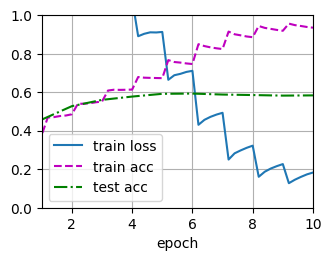

In [12]:
batch_size, num_epochs = 16, 10  # 与主 notebook 12.1 节的 PyPTO 训练配置一致

def train_with_data_aug_pypto(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction="none")
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, device)

def init_weights_pypto(m):
    if type(m) in (PyPTOLinear, PyPTOConv2d, nn.Linear, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)

# 不使用图像增广（PyPTO）
net = resnet18_pypto(10, 3).to(device)
net.apply(init_weights_pypto)
train_with_data_aug_pypto(test_augs, test_augs, net)


loss 0.668, train acc 0.762, test acc 0.607
191.2 examples/sec on npu:1


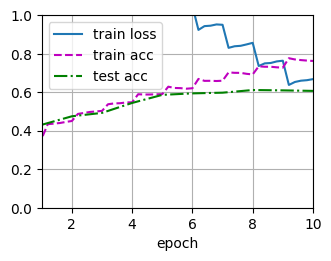

In [13]:
# 使用图像增广（PyPTO）
net = resnet18_pypto(10, 3).to(device)
net.apply(init_weights_pypto)
train_with_data_aug_pypto(train_augs, test_augs, net)

---


### 练习 12.1.2

**题目：** 在基于CIFAR-10数据集的模型训练中结合多种不同的图像增广方法。它能提高测试准确性吗？

**解答：**

&emsp;&emsp;理论上，组合多种增广（随机旋转、翻转、颜色抖动等）能让模型学到更鲁棒、更泛化的特征，从而提升测试精度。但增广本质是一种正则化：更强的增广需要更长的训练周期才能消化。本实验在 10 个迭代周期内，组合多种增广（`RandomRotation` + `RandomHorizontalFlip` + `ColorJitter`）的测试精度（torch 0.535 / PyPTO 0.554）反而低于仅水平翻转（torch 0.605 / PyPTO 0.607）与无增广（torch 0.566 / PyPTO 0.584）——强增广拖慢了收敛。读者可增大迭代周期或学习率观察其收益。

以下使用 `torch` 编程进行验证（组合多种增广，训练10个迭代周期）：


loss 1.313, train acc 0.524, test acc 0.535
1267.7 examples/sec on npu:1


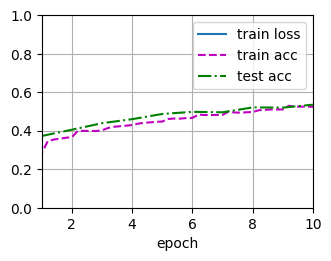

In [16]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomRotation(degrees=(-10, 10)),   # 随机旋转
    torchvision.transforms.RandomHorizontalFlip(p=0.5),         # 随机水平翻转
    torchvision.transforms.ColorJitter(                         # 颜色抖动
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    torchvision.transforms.ToTensor(),
])

net = resnet18(10, 3)
net.apply(init_weights)
train_with_data_aug(augs, test_augs, net)

使用 `PyPTO` 编程进行验证（同样组合多种增广，PyPTO 版训练 10 个迭代周期）：


loss 1.299, train acc 0.532, test acc 0.554
191.2 examples/sec on npu:1


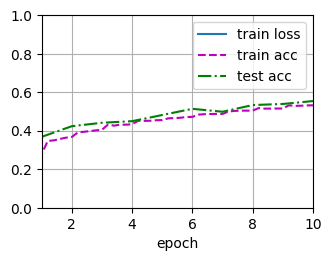

In [18]:
net = resnet18_pypto(10, 3).to(device)
net.apply(init_weights_pypto)
train_with_data_aug_pypto(augs, test_augs, net)

---


### 练习 12.1.3

**题目：** 参阅深度学习框架的在线文档。它还提供了哪些其他的图像增广方法？

**解答：**

&emsp;&emsp;PyTorch 的 `torchvision.transforms` 还提供了以下常用图像增广方法：

- **裁剪（Crop）**：中心裁剪`transforms.CenterCrop`、随机裁剪`transforms.RandomCrop`、随机长宽比裁剪`transforms.RandomResizedCrop`、五块/十块裁剪`transforms.FiveCrop`/`TenCrop`；
- **翻转和旋转（Flip and Rotation）**：随机水平翻转`RandomHorizontalFlip`、随机垂直翻转`RandomVerticalFlip`、随机旋转`RandomRotation`；
- **图像变换（Resize / Color）**：标准化`Normalize`、填充`Pad`、修改亮度/对比度/饱和度/色调`ColorJitter`、转灰度图`Grayscale`、仿射变换`RandomAffine`、依概率转灰度`RandomGrayscale`；
- **高级增广（v2 与自动增广）**：`transforms.v2.CutMix`（随机剪切一块区域并混合标签）、`transforms.v2.MixUp`（两张图像按权重混合生成新样本）、以及 `AutoAugment` / `RandAugment` / `TrivialAugmentWide`等自动增广策略。

&emsp;&emsp;更详细内容可参考 [PyTorch 官方文档](https://pytorch.org/vision/stable/transforms.html)。

以下使用 `torch` 编程进行验证（对示例图像依次应用几种增广）：


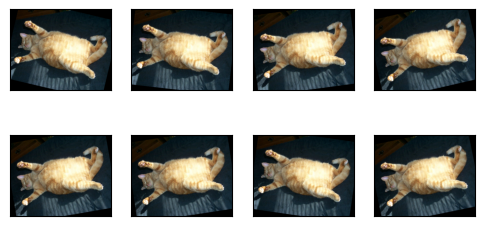

In [21]:
img = Image.open('../images/cat1.jpg')

def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    show_images(Y, num_rows, num_cols, scale=scale)

# 多种增广各展示一组结果
apply(img, torchvision.transforms.RandomRotation(degrees=(-15, 15)))

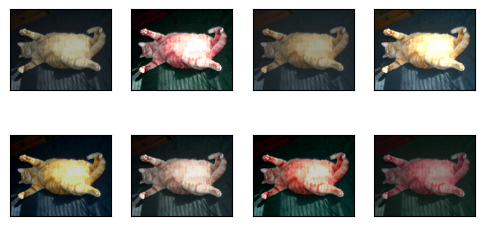

In [22]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2))

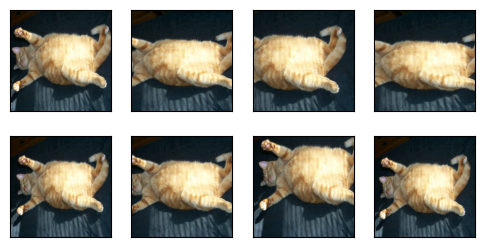

In [23]:
apply(img, torchvision.transforms.RandomResizedCrop(
    (300, 300), scale=(0.5, 1.0), ratio=(0.75, 1.333)))

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
